**Chapter 2 – End-to-end Machine Learning project**

Determinare diagnostic de AtrofieA pe baza oricaror coloane MACROSCOPIE

In [78]:
from __future__ import division, print_function, unicode_literals

import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd",category=FutureWarning)

In [79]:
# to make this notebook's output stable across runs
np.random.seed(42)

# Get the data

In [80]:
data = pd.read_csv('diseases.csv')

In [81]:
data

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
0,N,N,N,N,N,ERITEM,N,HEMOR,NU,D,N,N,0
1,PG,N,N,N,N,ERITEM,N,N,NU,A,N,N,FMP
2,N,E1,N,RDGE,BI,ERITEM,N,N,NU,A,N,N,0
3,PG,E1,N,N,BI,ERITEM,N,ERITEM,NU,D,N,N,0
4,N,E1,N,N,BI,ERITEM,N,N,NU,A,N,N,FMP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,N,E2,N,N,BI,NODULAR,N,N,NU,A,DISK,N,FMP
495,N,E1,N,VGI,N,EROZIV,N,N,NU,A,N,ATROFIC,0
496,N,N,N,VGI,N,ATROFIC,ATROFIC,N,NU,D,N,N,0
497,N,E1,N,N,BI,ERITEM,N,N,NU,A,N,N,FMP


In [82]:
data.shape

(499, 13)

In [83]:
data.head()

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
0,N,N,N,N,N,ERITEM,N,HEMOR,NU,D,N,N,0
1,PG,N,N,N,N,ERITEM,N,N,NU,A,N,N,FMP
2,N,E1,N,RDGE,BI,ERITEM,N,N,NU,A,N,N,0
3,PG,E1,N,N,BI,ERITEM,N,ERITEM,NU,D,N,N,0
4,N,E1,N,N,BI,ERITEM,N,N,NU,A,N,N,FMP


In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ESOFLUMEN     499 non-null    object
 1   ESOFMUC       499 non-null    object
 2   ESOFSFINCTER  499 non-null    object
 3   STOLUMEN      499 non-null    object
 4   STOCONTINUT   499 non-null    object
 5   STOMUCANTRU   499 non-null    object
 6   STOMUCCORP    499 non-null    object
 7   STOMUCFUND    499 non-null    object
 8   UGPOL         499 non-null    object
 9   LOCALIZARE    496 non-null    object
 10  PILOR         499 non-null    object
 11  MUCDUOD       499 non-null    object
 12  AtrofieA      499 non-null    object
dtypes: object(13)
memory usage: 50.8+ KB


In [85]:
data.describe()

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
count,499,499,499,499,499,499,499,499,499,496,499,499,499
unique,4,7,2,6,4,10,9,7,4,5,3,9,6
top,N,N,N,N,N,ERITEM,N,N,NU,A,N,N,0
freq,412,323,492,435,373,145,394,449,477,298,485,444,374


In [86]:
print(data.dtypes)

from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()

for column in data.columns:
    data[column] = labelEncoder.fit_transform(data[column].values)

print(f'\n{data.dtypes}')

data

ESOFLUMEN       object
ESOFMUC         object
ESOFSFINCTER    object
STOLUMEN        object
STOCONTINUT     object
STOMUCANTRU     object
STOMUCCORP      object
STOMUCFUND      object
UGPOL           object
LOCALIZARE      object
PILOR           object
MUCDUOD         object
AtrofieA        object
dtype: object

ESOFLUMEN       int64
ESOFMUC         int64
ESOFSFINCTER    int64
STOLUMEN        int64
STOCONTINUT     int64
STOMUCANTRU     int64
STOMUCCORP      int64
STOMUCFUND      int64
UGPOL           int64
LOCALIZARE      int64
PILOR           int64
MUCDUOD         int64
AtrofieA        int64
dtype: object


,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
0,1,4,1,1,2,1,5,3,1,2,1,5,0
1,2,4,1,1,2,1,5,5,1,0,1,5,4
2,1,1,1,3,1,1,5,5,1,0,1,5,0
3,2,1,1,1,1,1,5,1,1,2,1,5,0
4,1,1,1,1,1,1,5,5,1,0,1,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,1,2,1,1,1,9,5,5,1,0,0,5,4
495,1,1,1,5,2,2,5,5,1,0,1,0,0
496,1,4,1,5,2,0,0,5,1,2,1,5,0
497,1,1,1,1,1,1,5,5,1,0,1,5,4


In [87]:
data.describe(include='all')


,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,1.106212,3.020040,0.985972,1.388778,1.731463,3.909820,4.374749,4.667335,1.044088,1.112224,0.983968,4.779559,0.851703
std,0.418859,1.409805,0.117724,1.130605,0.514871,3.062581,1.582359,1.091016,0.320109,1.520750,0.166898,1.054491,1.579885
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,5.000000,5.000000,1.000000,0.000000,1.000000,5.000000,0.000000
50%,1.000000,4.000000,1.000000,1.000000,2.000000,4.000000,5.000000,5.000000,1.000000,0.000000,1.000000,5.000000,0.000000
75%,1.000000,4.000000,1.000000,1.000000,2.000000,6.000000,5.000000,5.000000,1.000000,2.000000,1.000000,5.000000,0.500000
max,3.000000,6.000000,1.000000,5.000000,3.000000,9.000000,8.000000,6.000000,3.000000,5.000000,2.000000,8.000000,5.000000


/home/sergiu/anaconda3/envs/sergiu/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


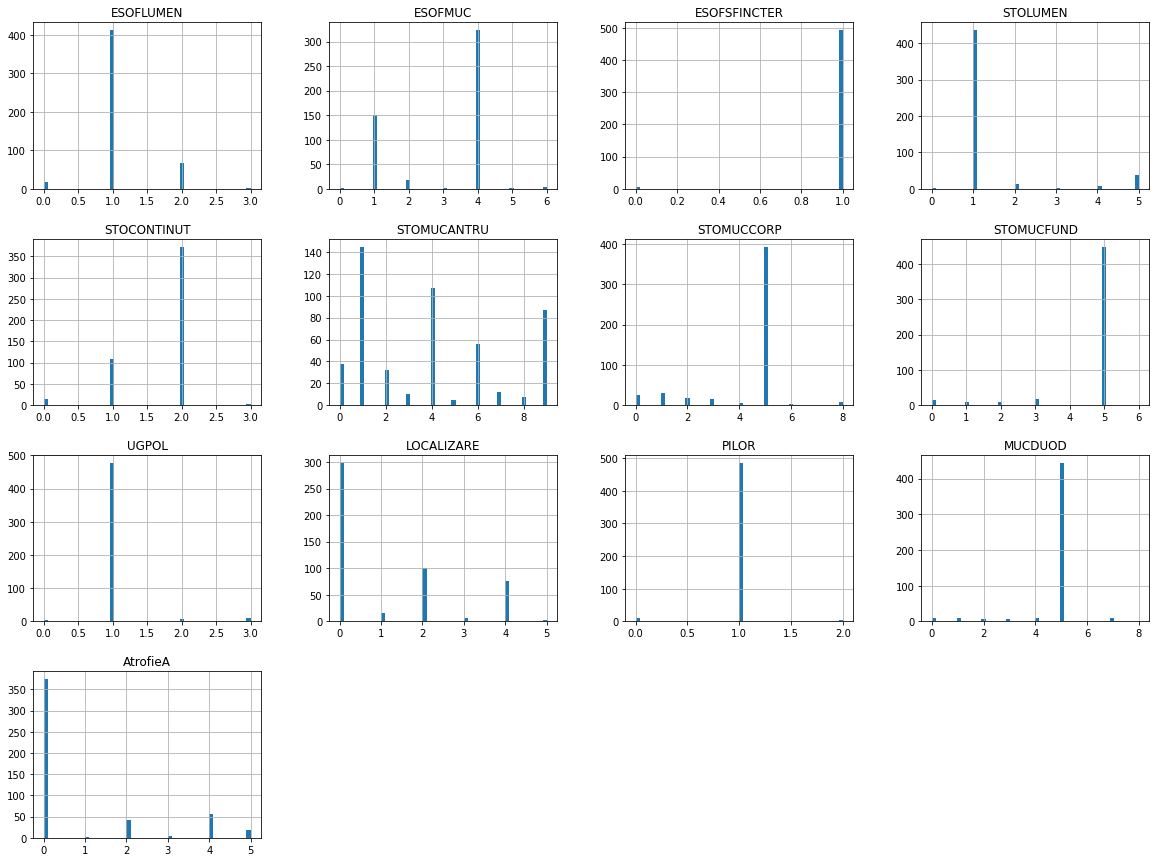

In [88]:
%matplotlib inline
data.hist(bins=50, figsize=(20,15))
plt.show()

In [89]:
ESOFLUMEN = data.groupby('ESOFLUMEN')['AtrofieA'].value_counts() / data.groupby('ESOFLUMEN')['AtrofieA'].count()

ESOFMUC = data.groupby('ESOFMUC')['AtrofieA'].value_counts() / data.groupby('ESOFMUC')['AtrofieA'].count()

ESOFSFINCTER = data.groupby('ESOFSFINCTER')['AtrofieA'].value_counts() / data.groupby('ESOFSFINCTER')['AtrofieA'].count()

STOLUMEN = data.groupby('STOLUMEN')['AtrofieA'].value_counts() / data.groupby('STOLUMEN')['AtrofieA'].count()

STOCONTINUT = data.groupby('STOCONTINUT')['AtrofieA'].value_counts() / data.groupby('STOCONTINUT')['AtrofieA'].count()

STOMUCANTRU = data.groupby('STOMUCANTRU')['AtrofieA'].value_counts() / data.groupby('STOMUCANTRU')['AtrofieA'].count()

STOMUCCORP = data.groupby('STOMUCCORP')['AtrofieA'].value_counts() / data.groupby('STOMUCCORP')['AtrofieA'].count()

STOMUCFUND = data.groupby('STOMUCFUND')['AtrofieA'].value_counts() / data.groupby('STOMUCFUND')['AtrofieA'].count()

UGPOL = data.groupby('UGPOL')['AtrofieA'].value_counts() / data.groupby('UGPOL')['AtrofieA'].count()

LOCALIZARE = data.groupby('LOCALIZARE')['AtrofieA'].value_counts() / data.groupby('LOCALIZARE')['AtrofieA'].count()

PILOR = data.groupby('PILOR')['AtrofieA'].value_counts() / data.groupby('PILOR')['AtrofieA'].count()

MUCDUOD = data.groupby('MUCDUOD')['AtrofieA'].value_counts() / data.groupby('MUCDUOD')['AtrofieA'].count()


print(ESOFLUMEN)
print(ESOFMUC)
print(ESOFSFINCTER)
print(STOLUMEN)
print(STOCONTINUT)
print(STOMUCANTRU)
print(STOMUCCORP)
print(STOMUCFUND)
print(UGPOL)
print(LOCALIZARE)
print(PILOR)
print(MUCDUOD)

ESOFLUMEN  AtrofieA
0          0           0.611111
           2           0.222222
           5           0.166667
1          0           0.762136
           4           0.116505
           2           0.077670
           5           0.033981
           3           0.007282
           1           0.002427
2          0           0.716418
           4           0.134328
           2           0.089552
           3           0.029851
           5           0.029851
3          0           0.500000
           2           0.500000
Name: AtrofieA, dtype: float64
ESOFMUC  AtrofieA
0        0           1.000000
1        0           0.693333
         4           0.126667
         2           0.113333
         5           0.053333
         1           0.006667
         3           0.006667
2        0           0.666667
         4           0.277778
         2           0.055556
3        2           0.500000
         5           0.500000
4        0           0.783282
         4           0.102167

In [90]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)
print(len(train_set), "train +", len(test_set), "test")
#delimitam datele in date de train si de test

399 train + 100 test


In [91]:
train_set

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
56,1,4,1,5,1,1,5,5,1,0,1,5,0
227,1,4,1,1,2,1,3,5,0,2,1,5,0
280,1,4,1,1,2,1,1,5,1,2,1,5,0
486,1,4,1,1,2,1,5,5,1,0,1,5,0
220,2,1,1,1,2,9,5,5,1,0,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,1,4,1,5,2,6,5,5,1,0,1,5,0
270,1,4,1,1,2,1,5,5,1,0,1,5,4
348,1,4,1,1,2,1,5,5,1,0,0,5,0
435,1,4,1,5,2,1,5,5,1,0,1,5,0


In [92]:
test_set


,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
460,1,4,1,1,2,9,5,5,1,0,1,5,0
73,1,4,1,1,2,0,0,0,1,2,1,5,0
231,1,4,1,5,2,4,5,5,2,4,1,5,0
175,1,4,1,1,2,4,5,5,1,4,1,5,0
237,1,4,1,1,2,4,5,5,1,4,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1,4,1,1,1,1,1,5,1,2,1,5,0
384,1,1,1,1,2,1,5,5,1,0,1,5,0
19,1,4,1,1,2,9,5,5,1,0,1,5,0
321,1,1,1,1,2,6,5,5,1,0,1,5,0


In [93]:
corr_matrix = data.corr()
corr_matrix

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA
ESOFLUMEN,1.000000,-0.204242,-0.091891,0.048317,-0.063014,0.007482,-0.029878,-0.093897,0.009934,-0.021903,0.024407,0.021292,-0.000426
ESOFMUC,-0.204242,1.000000,0.086389,-0.018756,0.192777,0.051578,-0.036678,-0.094876,-0.010861,0.106658,-0.075439,-0.002425,-0.085211
ESOFSFINCTER,-0.091891,0.086389,1.000000,-0.049462,0.103370,0.091166,0.092954,0.041764,0.016445,-0.024837,-0.113670,-0.024960,0.042774
STOLUMEN,0.048317,-0.018756,-0.049462,1.000000,-0.037613,-0.064085,-0.120886,0.009014,0.046866,0.024792,-0.009469,0.011395,0.040211
STOCONTINUT,-0.063014,0.192777,0.103370,-0.037613,1.000000,0.082668,0.007928,-0.034236,0.059795,0.087293,0.066639,-0.098156,-0.019432
STOMUCANTRU,0.007482,0.051578,0.091166,-0.064085,0.082668,1.000000,0.310299,0.208554,0.077801,-0.084483,0.024666,0.139951,-0.110257
STOMUCCORP,-0.029878,-0.036678,0.092954,-0.120886,0.007928,0.310299,1.000000,0.459685,0.046602,-0.190246,0.030399,0.121815,0.019865
STOMUCFUND,-0.093897,-0.094876,0.041764,0.009014,-0.034236,0.208554,0.459685,1.000000,0.001832,-0.211035,-0.018321,0.142088,0.086654
UGPOL,0.009934,-0.010861,0.016445,0.046866,0.059795,0.077801,0.046602,0.001832,1.000000,-0.043183,0.013257,0.082389,-0.026751
LOCALIZARE,-0.021903,0.106658,-0.024837,0.024792,0.087293,-0.084483,-0.190246,-0.211035,-0.043183,1.000000,0.007103,0.000432,-0.037355


Facem matricea de corelatii iar apoi o sortam in functie de importanta a ceea ce vrem sa determinam

In [94]:
corr_matrix["AtrofieA"].sort_values(ascending=False)


AtrofieA        1.000000
STOMUCFUND      0.086654
ESOFSFINCTER    0.042774
STOLUMEN        0.040211
STOMUCCORP      0.019865
ESOFLUMEN      -0.000426
STOCONTINUT    -0.019432
UGPOL          -0.026751
LOCALIZARE     -0.037355
ESOFMUC        -0.085211
MUCDUOD        -0.094392
STOMUCANTRU    -0.110257
PILOR          -0.176574
Name: AtrofieA, dtype: float64

/home/sergiu/anaconda3/envs/sergiu/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


array([[<AxesSubplot:xlabel='AtrofieA', ylabel='AtrofieA'>,
        <AxesSubplot:xlabel='STOLUMEN', ylabel='AtrofieA'>,
        <AxesSubplot:xlabel='STOMUCCORP', ylabel='AtrofieA'>,
        <AxesSubplot:xlabel='STOMUCFUND', ylabel='AtrofieA'>,
        <AxesSubplot:xlabel='ESOFSFINCTER', ylabel='AtrofieA'>],
       [<AxesSubplot:xlabel='AtrofieA', ylabel='STOLUMEN'>,
        <AxesSubplot:xlabel='STOLUMEN', ylabel='STOLUMEN'>,
        <AxesSubplot:xlabel='STOMUCCORP', ylabel='STOLUMEN'>,
        <AxesSubplot:xlabel='STOMUCFUND', ylabel='STOLUMEN'>,
        <AxesSubplot:xlabel='ESOFSFINCTER', ylabel='STOLUMEN'>],
       [<AxesSubplot:xlabel='AtrofieA', ylabel='STOMUCCORP'>,
        <AxesSubplot:xlabel='STOLUMEN', ylabel='STOMUCCORP'>,
        <AxesSubplot:xlabel='STOMUCCORP', ylabel='STOMUCCORP'>,
        <AxesSubplot:xlabel='STOMUCFUND', ylabel='STOMUCCORP'>,
        <AxesSubplot:xlabel='ESOFSFINCTER', ylabel='STOMUCCORP'>],
       [<AxesSubplot:xlabel='AtrofieA', ylabel='STOMUCFUND'>,
 

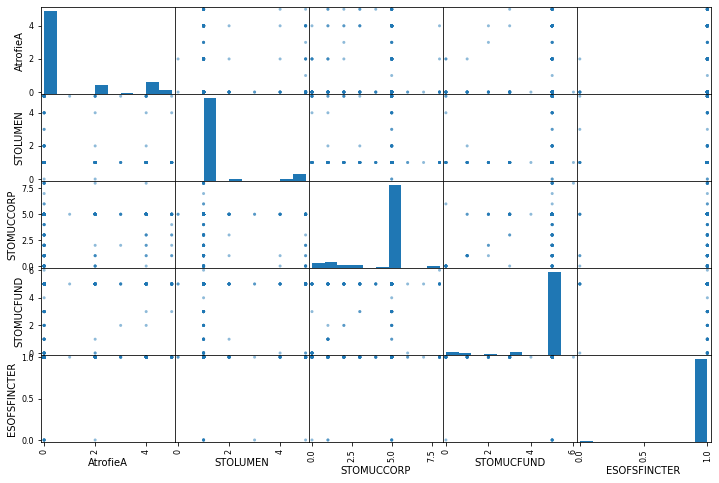

In [95]:
from pandas.plotting import scatter_matrix

attributes = ["AtrofieA","STOLUMEN", "STOMUCCORP", "STOMUCFUND", "ESOFSFINCTER" ]
scatter_matrix(data[attributes], figsize=(12, 8))

# Prepare the data for Machine Learning algorithms

Am eliminat coloana AtrofieA fiindca pe aceasta vrem sa o calculam

In [96]:
train_data_set=train_set.drop("AtrofieA", axis=1)
train_data_set_verify=train_set['AtrofieA'].copy()
train_data_set

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD
56,1,4,1,5,1,1,5,5,1,0,1,5
227,1,4,1,1,2,1,3,5,0,2,1,5
280,1,4,1,1,2,1,1,5,1,2,1,5
486,1,4,1,1,2,1,5,5,1,0,1,5
220,2,1,1,1,2,9,5,5,1,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
106,1,4,1,5,2,6,5,5,1,0,1,5
270,1,4,1,1,2,1,5,5,1,0,1,5
348,1,4,1,1,2,1,5,5,1,0,0,5
435,1,4,1,5,2,1,5,5,1,0,1,5


In [97]:
train_data_set_verify

56     0
227    0
280    0
486    0
220    0
      ..
106    0
270    4
348    0
435    0
102    0
Name: AtrofieA, Length: 399, dtype: int64

In [98]:
#am formatat fisierul incat sa nu avem date incomplete
sample_incomplete_rows = data[data.isnull().any(axis=1)].head()
print(sample_incomplete_rows)

Empty DataFrame
Columns: [ESOFLUMEN, ESOFMUC, ESOFSFINCTER, STOLUMEN, STOCONTINUT, STOMUCANTRU, STOMUCCORP, STOMUCFUND, UGPOL, LOCALIZARE, PILOR, MUCDUOD, AtrofieA]
Index: []


In [99]:
from sklearn.preprocessing import FunctionTransformer

stolumen, stomucantru = [
    list(data.columns).index(col)
    for col in ("STOLUMEN", "STOMUCANTRU")]

def add_extra_features(X):
    stolumen_stomucantru = X[:, stolumen] * X[:, stomucantru]
    return np.c_[X, stolumen_stomucantru]

attr_adder = FunctionTransformer(add_extra_features, validate=False)
data_extra_features = attr_adder.fit_transform(data.values)
data_extra_features

array([[1, 4, 1, ..., 5, 0, 1],
       [2, 4, 1, ..., 5, 4, 1],
       [1, 1, 1, ..., 5, 0, 3],
       ...,
       [1, 4, 1, ..., 5, 0, 0],
       [1, 1, 1, ..., 5, 4, 1],
       [1, 4, 1, ..., 5, 0, 8]])

In [100]:
data_extra_features = pd.DataFrame(
    data_extra_features,
    columns=list(data.columns)+["STOLUMEN_STOMUCANTRU"])
data_extra_features

,ESOFLUMEN,ESOFMUC,ESOFSFINCTER,STOLUMEN,STOCONTINUT,STOMUCANTRU,STOMUCCORP,STOMUCFUND,UGPOL,LOCALIZARE,PILOR,MUCDUOD,AtrofieA,STOLUMEN_STOMUCANTRU
0,1,4,1,1,2,1,5,3,1,2,1,5,0,1
1,2,4,1,1,2,1,5,5,1,0,1,5,4,1
2,1,1,1,3,1,1,5,5,1,0,1,5,0,3
3,2,1,1,1,1,1,5,1,1,2,1,5,0,1
4,1,1,1,1,1,1,5,5,1,0,1,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,1,2,1,1,1,9,5,5,1,0,0,5,4,9
495,1,1,1,5,2,2,5,5,1,0,1,0,0,10
496,1,4,1,5,2,0,0,5,1,2,1,5,0,0
497,1,1,1,1,1,1,5,5,1,0,1,5,4,1


In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
try:
    from sklearn.impute import SimpleImputer # Scikit-Learn 0.20+
except ImportError:
    from sklearn.preprocessing import Imputer as SimpleImputer

full_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', FunctionTransformer(add_extra_features, validate=False)),
        ('std_scaler', StandardScaler()),
    ])

data_transform = full_pipeline.fit_transform(data_extra_features)
data_transform

array([[-0.25382979,  0.69580084,  0.11927968, ..., -0.53963305,
        -0.66855964, -0.66855964],
       [ 2.13600161,  0.69580084,  0.11927968, ...,  1.9947377 ,
        -0.66855964, -0.66855964],
       [-0.25382979, -1.43428885,  0.11927968, ..., -0.53963305,
        -0.35083463, -0.35083463],
       ...,
       [-0.25382979,  0.69580084,  0.11927968, ..., -0.53963305,
        -0.82742215, -0.82742215],
       [-0.25382979, -1.43428885,  0.11927968, ...,  1.9947377 ,
        -0.66855964, -0.66855964],
       [-0.25382979,  0.69580084,  0.11927968, ..., -0.53963305,
         0.44347789,  0.44347789]])

In [102]:
data_transform.shape



(499, 15)

# Select and train some models 

In [103]:
train, test = train_test_split(data_extra_features, test_size=0.2, random_state=42)
print(len(train), "train +", len(test), "test")

399 train + 100 test


In [104]:
x=train.drop(["AtrofieA"], axis=1)
y=train["AtrofieA"].copy()

In [105]:
full_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', FunctionTransformer(add_extra_features, validate=False)),
        ('std_scaler', StandardScaler()),
    ])

x_tr = full_pipeline.fit_transform(x)

In [106]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_tr, y)

LinearRegression()

In [107]:
print(x)
some_data = x.iloc[:7]
some_labels = y
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Predictions:", lin_reg.predict(x_tr))

     ESOFLUMEN  ESOFMUC  ESOFSFINCTER  STOLUMEN  STOCONTINUT  STOMUCANTRU  \
56           1        4             1         5            1            1   
227          1        4             1         1            2            1   
280          1        4             1         1            2            1   
486          1        4             1         1            2            1   
220          2        1             1         1            2            9   
..         ...      ...           ...       ...          ...          ...   
106          1        4             1         5            2            6   
270          1        4             1         1            2            1   
348          1        4             1         1            2            1   
435          1        4             1         5            2            1   
102          1        4             1         1            1            2   

     STOMUCCORP  STOMUCFUND  UGPOL  LOCALIZARE  PILOR  MUCDUOD  \
56       

In [108]:
print("Labels:", list(some_labels))

Labels: [0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 4, 0, 0, 0, 0, 2, 0, 0, 2, 4, 0, 4, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 0, 3, 2, 0, 0, 0, 4, 0, 5, 0, 4, 0, 4, 0, 2, 0, 4, 0, 0, 0, 0, 0, 0, 0, 2, 0, 4, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 5, 0, 0, 4, 0, 0, 0, 0, 0, 5, 5, 4, 0, 2, 4, 0, 4, 0, 3, 4, 0, 0, 0, 0, 5, 0, 0, 2, 4, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 5, 4, 3, 4, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 5, 5, 0, 0, 0, 0, 0, 4, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 4, 0, 0, 5, 0, 0, 2, 0, 5, 0, 0, 0, 0, 2, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 0, 2, 0, 0, 0, 0, 0, 0, 4, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2

In [109]:
some_data_prepared

array([[-2.41859095e-01,  6.70699667e-01,  1.12651477e-01,
         3.13780889e+00, -1.44766122e+00, -9.20485233e-01,
         3.71299772e-01,  3.14336278e-01, -1.18091933e-01,
        -7.11373547e-01,  8.37296614e-02,  1.95882024e-01,
        -1.70034066e-03, -1.70034066e-03],
       [-2.41859095e-01,  6.70699667e-01,  1.12651477e-01,
        -3.47189711e-01,  5.17021865e-01, -9.20485233e-01,
        -9.00362107e-01,  3.14336278e-01, -3.25933736e+00,
         6.02691477e-01,  8.37296614e-02,  1.95882024e-01,
        -6.80136265e-01, -6.80136265e-01],
       [-2.41859095e-01,  6.70699667e-01,  1.12651477e-01,
        -3.47189711e-01,  5.17021865e-01, -9.20485233e-01,
        -2.17202399e+00,  3.14336278e-01, -1.18091933e-01,
         6.02691477e-01,  8.37296614e-02,  1.95882024e-01,
        -6.80136265e-01, -6.80136265e-01],
       [-2.41859095e-01,  6.70699667e-01,  1.12651477e-01,
        -3.47189711e-01,  5.17021865e-01, -9.20485233e-01,
         3.71299772e-01,  3.14336278e-01, -1.

In [110]:
from sklearn.metrics import mean_squared_error

data_predictions = lin_reg.predict(x_tr)
lin_mse = mean_squared_error(y, data_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

1.5274231345047267

In [111]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(y, data_predictions)
lin_mae

1.198407456947149

In [112]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(x_tr, y)

DecisionTreeRegressor(random_state=42)

In [113]:
data_predictions = tree_reg.predict(x_tr)
tree_mse = mean_squared_error(y, data_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

1.0786839113296465

In [114]:
x = data.iloc[:, 0:len(data.columns) - 1].values
y = data['AtrofieA'].values

print(x)
print(y)

[[1 4 1 ... 2 1 5]
 [2 4 1 ... 0 1 5]
 [1 1 1 ... 0 1 5]
 ...
 [1 4 1 ... 2 1 5]
 [1 1 1 ... 0 1 5]
 [1 4 1 ... 4 1 5]]
[0 4 0 0 4 3 5 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 2 0 0 0 2 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 4 2 2 0 0 0 0 0 0 0 4 4 4 0 0 0 0 1 0 5 0 5 0 0 2 0
 4 0 0 0 0 2 0 0 0 2 0 5 4 0 0 0 4 2 5 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 4 0 2 2 2 2 0 0 0 0 0 4 0 0 0 2 2 0 0 0 0 4 0 0 0 4 0 0 0 0 0 0 0 0 0
 0 5 0 4 5 0 4 0 0 0 0 0 2 4 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 4 0 2 0
 4 0 0 0 2 0 0 2 0 0 0 0 0 5 0 0 0 0 2 0 0 0 0 0 0 0 0 5 0 4 0 2 0 0 0 0 0
 3 5 0 0 0 0 0 2 2 0 0 0 4 0 0 0 0 0 2 2 0 0 0 2 2 0 4 0 0 0 4 0 0 2 0 0 0
 0 0 0 0 0 0 0 4 2 0 4 4 0 0 0 0 0 0 0 0 3 0 5 0 0 0 0 0 0 0 0 0 4 0 0 0 0
 5 0 0 0 0 0 0 0 0 0 4 0 0 0 0 5 0 0 0 0 0 4 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 4 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 4 2 0 0 4 4 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 5 4 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 4 4 0 0 0 4 0 4 5 3 2 0 0 0 0 2
 0 0 4 0 0 5 0 0 0 2 0 0 0 0 4 2 0 0 0 0 0 0 0 0 0 0 0 

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [116]:
def models(x_train, y_train):
    from sklearn.tree import DecisionTreeClassifier
    tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
    tree.fit(x_train, y_train)
    
    print(f'Accuracy = {tree.score(x_train, y_train)}')
    
    return tree


In [117]:
model = models(x_train, y_train)

print(model)

Accuracy = 0.8521303258145363
DecisionTreeClassifier(criterion='entropy', random_state=0)


In [118]:
feature_importance = pd.DataFrame({'feature': data.iloc[:, 0:len(data.columns) - 1].columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending = False).set_index('feature')
print(feature_importance)

              importance
feature                 
ESOFMUC         0.157490
STOCONTINUT     0.145115
STOMUCANTRU     0.140315
STOMUCCORP      0.109403
ESOFLUMEN       0.103515
STOLUMEN        0.087877
MUCDUOD         0.078235
LOCALIZARE      0.066041
STOMUCFUND      0.053292
PILOR           0.031538
UGPOL           0.022856
ESOFSFINCTER    0.004322
